In [ ]:
!pip -q install torch torchvision numpy pandas scipy scikit-learn

import os, ast
import numpy as np
import pandas as pd

from scipy.signal import butter, filtfilt, stft
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.models import resnet18, ResNet18_Weights

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE = "/content/drive/MyDrive/Colab Notebooks"

X = np.load(f"{BASE}/X_ptbxl_500hz.npy", mmap_mode="r")
print("X:", X.shape)  # (21799, 12, 5000)

df = pd.read_csv(f"{BASE}/ptbxl_database.csv")
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

classes = ["NORM", "IMI", "ASMI", "LVH", "NDT", "LAFB"]
class_to_idx = {c:i for i,c in enumerate(classes)}

Y = np.zeros((len(df), len(classes)), dtype=np.float32)
for i, codes in enumerate(df["scp_codes"]):
    for c in classes:
        if c in codes:
            Y[i, class_to_idx[c]] = 1.0

print("Y:", Y.shape)
print("Counts:", dict(zip(classes, Y.sum(axis=0).astype(int))))
assert X.shape[0] == Y.shape[0]

X: (21799, 12, 5000)
Y: (21799, 6)
Counts: {'NORM': np.int64(9514), 'IMI': np.int64(2676), 'ASMI': np.int64(2357), 'LVH': np.int64(2132), 'NDT': np.int64(1825), 'LAFB': np.int64(1623)}


In [ ]:
def bandpass_filter(x, fs=500, low=0.5, high=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x, axis=0)

def ecg_to_spectrogram_tensor(ecg_time_leads, fs=500, win_len=256, hop=128, nfft=512, fmax=40.0):
    specs = []
    for lead in range(ecg_time_leads.shape[1]):
        f, tt, Z = stft(
            ecg_time_leads[:, lead],
            fs=fs,
            nperseg=win_len,
            noverlap=win_len-hop,
            nfft=nfft,
            boundary=None,
            padded=False
        )
        mag = np.abs(Z)
        keep = f <= fmax
        mag = mag[keep, :]
        mag = np.log1p(mag)
        mag = (mag - mag.mean()) / (mag.std() + 1e-8)
        specs.append(mag.astype(np.float32))
    return np.stack(specs, axis=0)  # (12, F, T)

In [ ]:
class PTBXLResNetDataset(Dataset):
    def __init__(self, X_mmap, Y, fs=500, out_size=224):
        self.X = X_mmap
        self.Y = Y
        self.fs = fs
        self.out_size = out_size

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        ecg = self.X[idx].T  # (5000, 12)

        ecg = bandpass_filter(ecg, fs=self.fs, low=0.5, high=40.0)
        ecg = (ecg - ecg.mean(axis=0)) / (ecg.std(axis=0) + 1e-8)

        spec = ecg_to_spectrogram_tensor(ecg, fs=self.fs)  # (12, 41, 38)
        x = torch.from_numpy(spec)  # (12, 41, 38)

        # Resize to (12, 224, 224)
        x = x.unsqueeze(0)  # (1, 12, 41, 38)
        x = F.interpolate(x, size=(self.out_size, self.out_size), mode="bilinear", align_corners=False)
        x = x.squeeze(0)    # (12, 224, 224)

        y = torch.from_numpy(self.Y[idx]).float()  # (6,)
        return x, y

In [ ]:
idx_all = np.arange(X.shape[0])
train_idx, val_idx = train_test_split(idx_all, test_size=0.2, random_state=42)

train_ds = torch.utils.data.Subset(PTBXLResNetDataset(X, Y), train_idx)
val_ds   = torch.utils.data.Subset(PTBXLResNetDataset(X, Y), val_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
def make_resnet18_12ch(num_classes=6):
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = resnet18(weights=weights)

    # --- change first conv from 3->12 channels ---
    old_conv = model.conv1  # (64, 3, 7, 7)
    new_conv = nn.Conv2d(12, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                         stride=old_conv.stride, padding=old_conv.padding, bias=False)

    # initialize new conv using pretrained weights:
    # average RGB weights and repeat to 12 channels
    with torch.no_grad():
        w = old_conv.weight  # (64, 3, 7, 7)
        w_mean = w.mean(dim=1, keepdim=True)  # (64, 1, 7, 7)
        new_conv.weight.copy_(w_mean.repeat(1, 12, 1, 1))

    model.conv1 = new_conv

    # --- change classifier head ---
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

device = "cuda" if torch.cuda.is_available() else "cpu"
model = make_resnet18_12ch(num_classes=len(classes)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # smaller LR for transfer learning
print("Device:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Device: cuda


In [ ]:
# Recommended training trick (optional but helpful): freeze backbone for 1–2 epochs, then unfreeze.

# Freeze everything except fc for warm start
for name, p in model.named_parameters():
    p.requires_grad = ("fc" in name)

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

In [ ]:
# After 1–2 epochs, unfreeze all:

for p in model.parameters():
    p.requires_grad = True
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def run_epoch(model, loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def get_outputs(model, loader):
    model.eval()
    all_true, all_prob = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        probs = torch.sigmoid(model(xb)).cpu().numpy()
        all_prob.append(probs)
        all_true.append(yb.numpy())
    return np.vstack(all_true), np.vstack(all_prob)

EPOCHS = 30
for epoch in range(1, EPOCHS+1):
    tr_loss = run_epoch(model, train_loader, training=True)
    va_loss = run_epoch(model, val_loader, training=False)
    print(f"Epoch {epoch}: train_loss={tr_loss:.4f} val_loss={va_loss:.4f}")

y_true, y_prob = get_outputs(model, val_loader)
y_pred = (y_prob >= 0.5).astype(int)

Epoch 1: train_loss=0.2749 val_loss=0.2335
Epoch 2: train_loss=0.2232 val_loss=0.2227
Epoch 3: train_loss=0.2020 val_loss=0.2248
Epoch 4: train_loss=0.1822 val_loss=0.2422
Epoch 5: train_loss=0.1560 val_loss=0.2374
Epoch 6: train_loss=0.1207 val_loss=0.2774
Epoch 7: train_loss=0.0793 val_loss=0.2895
Epoch 8: train_loss=0.0513 val_loss=0.3344
Epoch 9: train_loss=0.0380 val_loss=0.3810
Epoch 10: train_loss=0.0292 val_loss=0.3833
Epoch 11: train_loss=0.0253 val_loss=0.3984
Epoch 12: train_loss=0.0230 val_loss=0.4078
Epoch 13: train_loss=0.0189 val_loss=0.4193
Epoch 14: train_loss=0.0192 val_loss=0.4564
Epoch 15: train_loss=0.0176 val_loss=0.4553
Epoch 16: train_loss=0.0148 val_loss=0.4710
Epoch 17: train_loss=0.0162 val_loss=0.4607
Epoch 18: train_loss=0.0141 val_loss=0.4907
Epoch 19: train_loss=0.0123 val_loss=0.4968
Epoch 20: train_loss=0.0166 val_loss=0.5191
Epoch 21: train_loss=0.0154 val_loss=0.4969
Epoch 22: train_loss=0.0105 val_loss=0.5313
Epoch 23: train_loss=0.0098 val_loss=0.52

In [ ]:
print("Macro F1:", f1_score(y_true, y_pred, average="macro", zero_division=0))
print("Micro F1:", f1_score(y_true, y_pred, average="micro", zero_division=0))

Macro F1: 0.5534867745839022
Micro F1: 0.66196651139368


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Threshold = 0.5 (baseline)
y_pred = (y_prob >= 0.5).astype(int)

In [ ]:
print("Per-Class Metrics (ResNet18)\n")

for k, name in enumerate(classes):
    precision = precision_score(y_true[:, k], y_pred[:, k], zero_division=0)
    recall    = recall_score(y_true[:, k], y_pred[:, k], zero_division=0)
    f1        = f1_score(y_true[:, k], y_pred[:, k], zero_division=0)
    acc       = accuracy_score(y_true[:, k], y_pred[:, k])

    print(f"{name}:")
    print(f"  Precision = {precision:.4f}")
    print(f"  Recall    = {recall:.4f}")
    print(f"  F1-score  = {f1:.4f}")
    print(f"  Accuracy  = {acc:.4f}")
    print("-" * 40)

Per-Class Metrics (ResNet18)

NORM:
  Precision = 0.8304
  Recall    = 0.7993
  F1-score  = 0.8145
  Accuracy  = 0.8374
----------------------------------------
IMI:
  Precision = 0.4476
  Recall    = 0.6012
  F1-score  = 0.5132
  Accuracy  = 0.8642
----------------------------------------
ASMI:
  Precision = 0.5698
  Recall    = 0.6227
  F1-score  = 0.5951
  Accuracy  = 0.9057
----------------------------------------
LVH:
  Precision = 0.4715
  Recall    = 0.4847
  F1-score  = 0.4780
  Accuracy  = 0.9048
----------------------------------------
NDT:
  Precision = 0.4058
  Recall    = 0.1667
  F1-score  = 0.2363
  Accuracy  = 0.9170
----------------------------------------
LAFB:
  Precision = 0.7413
  Recall    = 0.6347
  F1-score  = 0.6839
  Accuracy  = 0.9550
----------------------------------------


In [ ]:
print("\nOverall Metrics (ResNet18)\n")

print("Macro Precision:", precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro Recall   :", recall_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro F1       :", f1_score(y_true, y_pred, average="macro", zero_division=0))

print("Micro Precision:", precision_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro Recall   :", recall_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro F1       :", f1_score(y_true, y_pred, average="micro", zero_division=0))


Overall Metrics (ResNet18)

Macro Precision: 0.577727315822514
Macro Recall   : 0.5515348131739194
Macro F1       : 0.5534867745839022
Micro Precision: 0.6691270043268007
Micro Recall   : 0.6549576482311908
Micro F1       : 0.66196651139368


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

per_class_acc = []

print("\nPer-Label Accuracy:\n")

for k, name in enumerate(classes):
    acc = accuracy_score(y_true[:, k], y_pred[:, k])
    per_class_acc.append(acc)
    print(f"{name}: {acc:.4f}")

macro_accuracy = np.mean(per_class_acc)

print("\nMacro Accuracy:", macro_accuracy)


Per-Label Accuracy:

NORM: 0.8374
IMI: 0.8642
ASMI: 0.9057
LVH: 0.9048
NDT: 0.9170
LAFB: 0.9550

Macro Accuracy: 0.8973623853211009


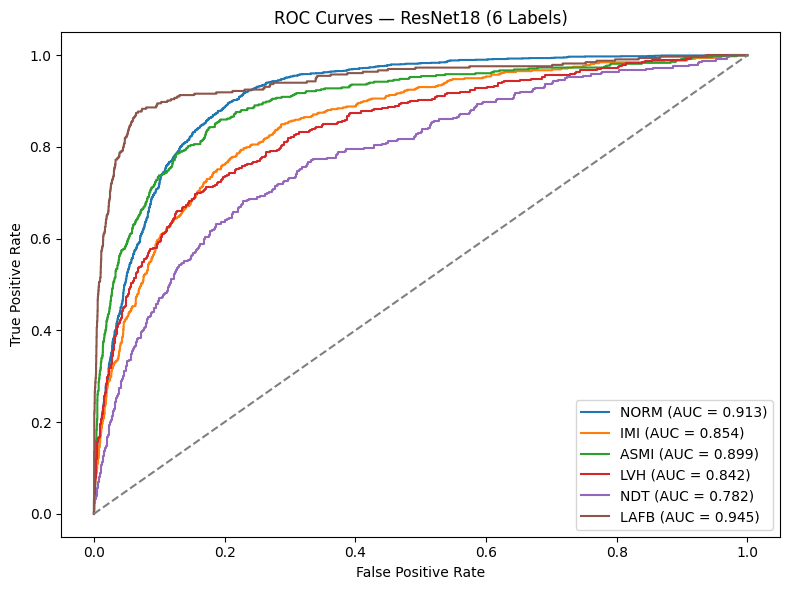

Macro AUROC: 0.8723391133379886


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

plt.figure(figsize=(8,6))

aucs = []

for k, name in enumerate(classes):
    if len(np.unique(y_true[:, k])) < 2:
        print(f"{name}: ROC not defined (only one class present)")
        continue

    fpr, tpr, _ = roc_curve(y_true[:, k], y_prob[:, k])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — ResNet18 (6 Labels)")
plt.legend()
plt.tight_layout()
plt.savefig("roc_resnet18.png", dpi=300)
plt.show()

print("Macro AUROC:", np.mean(aucs))